# TP3 — 06: Interpretacion del modelo

**Objetivo:** entender que aprendio el modelo (que palabras pesan mas para cada
polaridad) y aplicar la **similitud coseno**, la metrica de NLP vista en clase que
pide la consigna.

Alcance: esta version se enfoca en las dos partes que pudimos analizar en
profundidad — coeficientes del modelo y similitud coseno. Quedan afuera como
extension pendiente: modelado de topicos, analisis de sarcasmo y analisis por
usuario.

Se usa el **modelo final entrenado sobre los 1.600.000 tweets**.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils import (
    TARGET,
    TRAIN_CLEAN_PARQUET,
    VECTORIZER_JOBLIB,
    MODELO_JOBLIB,
    guardar_fig,
    COLOR_NEG,
    COLOR_POS,
)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
})
pd.set_option("display.max_colwidth", 140)

vec = joblib.load(VECTORIZER_JOBLIB)
lr = joblib.load(MODELO_JOBLIB)
train = pd.read_parquet(TRAIN_CLEAN_PARQUET)
assert len(train) == 1_600_000
vocab = vec.get_feature_names_out()
print(f"Modelo final cargado: {len(vocab):,} n-gramas en el vocabulario")

Modelo final cargado: 379,089 n-gramas en el vocabulario


## 1. Que aprendio el modelo: coeficientes por n-grama

En una regresion logistica sobre TF-IDF, cada n-grama tiene un coeficiente: positivo
empuja hacia sentimiento positivo, negativo hacia el negativo. Son las "palabras
mas predictivas", que no coinciden necesariamente con las mas frecuentes del EDA.

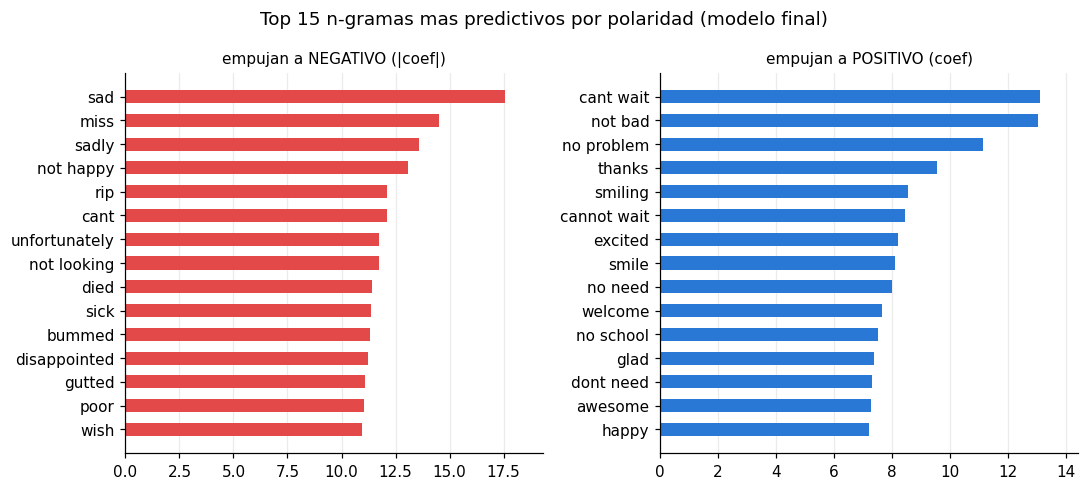

In [2]:
coefs = lr.coef_.ravel()
orden = np.argsort(coefs)
top_neg = pd.Series(coefs[orden[:15]], index=vocab[orden[:15]])
top_pos = pd.Series(coefs[orden[-15:]], index=vocab[orden[-15:]])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].barh(top_neg.index[::-1], -top_neg.values[::-1], height=0.55, color=COLOR_NEG)
axes[0].set_title("empujan a NEGATIVO (|coef|)", fontsize=10)
axes[1].barh(top_pos.index, top_pos.values, height=0.55, color=COLOR_POS)
axes[1].set_title("empujan a POSITIVO (coef)", fontsize=10)
for ax in axes:
    ax.grid(axis="y", alpha=0)
    ax.margins(x=0.1)
fig.suptitle("Top 15 n-gramas mas predictivos por polaridad (modelo final)")
fig.tight_layout()
guardar_fig(fig, "06_coeficientes.png")
plt.show()

**Analisis propio**: entre los terminos que mas empujan a POSITIVO aparecen varios
bigramas con negacion: `cant wait`, `not bad`, `no problem`, `no need`, `no school`,
`dont need`. Esto confirma la decision de preprocesamiento tomada en la notebook 03
de **conservar las negaciones** en vez de tratarlas como stopwords. Si se hubiera
sacado la palabra `not` de `not bad`, el bigrama hubiera quedado solo como `bad`,
que el modelo aprenderia como negativo — exactamente el sentido contrario al real.
Es decir, el resultado del propio modelo termina siendo evidencia a favor de esa
decision, tomada antes de ver estos coeficientes.

## 2. Similitud coseno (metrica de clase vista en clase)

La similitud coseno sirve para medir que tan parecidos son dos textos segun las
palabras que comparten. Da un valor entre 0 y 1: 0 significa que no comparten
vocabulario y 1 que, para esta representacion, usan exactamente el mismo
vocabulario.

In [3]:
# Matriz TF-IDF del corpus completo (los vectores salen normalizados en L2).
X = vec.transform(train["text_clean"])
print(f"Matriz TF-IDF: {X.shape[0]:,} x {X.shape[1]:,}")

Matriz TF-IDF: 1,600,000 x 379,089


### Ejemplo: tweets vecinos

Dado un tweet, se buscan los tweets con mayor similitud coseno (los que comparten
mas vocabulario).

In [4]:
def vecinos(idx_consulta, k=5):
    sims = (X @ X[idx_consulta].T).toarray().ravel()
    sims[idx_consulta] = -1  # excluye el propio tweet
    top = np.argsort(sims)[::-1][:k]
    print(f"CONSULTA [{ 'pos' if train.loc[idx_consulta, TARGET] == 4 else 'neg' }]: {train.loc[idx_consulta, 'text']}")
    for i in top:
        et = "pos" if train.loc[i, TARGET] == 4 else "neg"
        print(f"  cos={sims[i]:.3f} [{et}] {train.loc[i, 'text']}")
    print()

vecinos(train.index[(train[TARGET] == 4)][123])

CONSULTA [pos]: @suitelifeofkell that's freakin' cooool   i love twitter .haha
  cos=0.537 [pos] @rickseibold that's freakin awesome!!! 
  cos=0.458 [pos] @GiulianaRancic that's freakin hilarous how funny 
  cos=0.453 [pos] i love twitter 
  cos=0.453 [pos] I LOVE TWITTER 
  cos=0.453 [pos] i love twitter 



**Analisis propio**: el tweet "freakin' cooool i love twitter" encontro textos
cercanos por dos razones distintas: algunos compartian la palabra "freakin" y otros
compartian la frase "i love twitter". Eso muestra que la similitud puede venir de
coincidencias diferentes dentro del texto.

### Busqueda de posibles etiquetas mal puestas

Ademas de buscar tweets parecidos, la similitud coseno sirve para revisar la calidad
de las etiquetas: si dos tweets son casi identicos (similitud muy alta) pero tienen
etiquetas opuestas, es una senial de que al menos una de las dos esta mal puesta —
la misma idea que los duplicados exactos de la notebook 01, pero permitiendo textos
parecidos y no solo identicos letra por letra.

In [5]:
from utils import SEED

# Se prueban 300 tweets negativos como consulta y se busca, para cada uno, el
# tweet mas parecido en TODO el corpus.
rng = np.random.default_rng(SEED)
consultas = rng.choice(train.index[train[TARGET] == 0], size=300, replace=False)
sims_bloque = (X[consultas] @ X.T).toarray()
sims_bloque[np.arange(len(consultas)), consultas] = -1

pares = []
for fila, iq in enumerate(consultas):
    j = sims_bloque[fila].argmax()
    if sims_bloque[fila, j] > 0.8 and train.loc[j, TARGET] != train.loc[iq, TARGET]:
        pares.append((sims_bloque[fila, j], train.loc[iq, "text"], train.loc[j, "text"]))

print(f"De 300 tweets negativos consultados, se encontraron {len(pares)} caso(s)")
print("con un vecino MUY parecido (similitud > 0.8) pero de etiqueta OPUESTA.\n")
for s, a, b in sorted(pares, reverse=True):
    print(f"coseno={s:.3f}")
    print(f"  [negativo] {a}")
    print(f"  [positivo] {b}")

De 300 tweets negativos consultados, se encontraron 1 caso(s)
con un vecino MUY parecido (similitud > 0.8) pero de etiqueta OPUESTA.

coseno=1.000
  [negativo] two exams down  8 more to go though  !
  [positivo] two exams down  8 more to go though  !


**Analisis propio**: sobre esta muestra de 300 tweets negativos, aparecio un caso
con similitud maxima (coseno = 1,000) pero con etiqueta opuesta. Sin embargo, no fue
un hallazgo nuevo de textos "parecidos pero no iguales": era el mismo tipo de caso
ya visto en la notebook 01, con texto identico y distinta etiqueta. La principal
limitacion es que 300 tweets es una muestra chica frente al total (1.600.000), asi
que no se puede concluir que no exista ruido mas sutil (tweets parecidos pero no
identicos, con etiquetas opuestas) — solo que no aparecio en esta muestra puntual.

## Conclusiones de esta notebook

1. El modelo aprendio senial real de sentimiento: los n-gramas mas predictivos son
   inequivocos (`sad`, `poor`, `gutted` vs `thanks`, `smiling`, `blessed`), y varios
   de los mas positivos contienen negaciones (`not bad`, `no problem`), lo que
   confirma la decision de conservarlas en el preprocesamiento.
2. La similitud coseno permitio dos cosas: encontrar tweets con vocabulario
   parecido (util para entender por que el modelo los trataria similar) y buscar
   posibles etiquetas mal puestas de forma mas amplia que la comparacion de texto
   exacto de la notebook 01 — aunque en esta muestra puntual no aparecieron casos
   nuevos, solo se confirmo el tipo de ruido ya conocido.
3. **Extension pendiente**: quedan afuera de esta entrega el modelado de topicos,
   el analisis de sarcasmo/errores y el analisis por usuario, que estaban
   planificados pero se priorizo profundizar el analisis de lo obligatorio antes
   que cubrir mas superficie.